In [181]:
import os
import math
import torch
import tiktoken
import urllib.request 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from pathlib import Path
from tqdm.auto import tqdm

In [182]:
tokenizer = tiktoken.get_encoding("gpt2")

In [183]:
def download_the_verdict():
    url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt"
    data_dir = os.path.join(os.getcwd() , 'data','the-verdict')
    os.makedirs(data_dir ,exist_ok=True)
    file_path = os.path.join(data_dir, 'the-verdict.txt')
    if not os.path.exists(file_path):
        urllib.request.urlretrieve(url,file_path)
    with open(file_path,'r') as f:
        return f.read()


In [184]:
class VerdictDataset(Dataset):
    def __init__(self,raw_text,tokenizer, train_config):
        super().__init__()
        tokenized_text = tokenizer.encode(raw_text)
        self.X = []
        self.y = []
        for i in range(0,len(tokenized_text)-train_config.context_length,train_config.stride):
            self.X.append(torch.tensor(tokenized_text[i:i+train_config.context_length]))
            self.y.append(torch.tensor(tokenized_text[i+1:i+train_config.context_length+1]))
        self.X = torch.stack(self.X)
        self.y = torch.stack(self.y)


    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx],self.y[idx]

In [185]:
def create_dataloader(text,train_config):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = VerdictDataset(text,tokenizer,train_config)
    return DataLoader(dataset, batch_size=train_config.batch_size, shuffle=train_config.shuffle, drop_last=train_config.drop_last, num_workers=train_config.num_workers)

In [186]:
def generate_sample_text(model,device, tokenizer, text, max_new_tokens):
    model.eval()

    tokens = torch.tensor([tokenizer.encode(text)]).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):

            logits = model(tokens)

            next_token = torch.argmax(
                logits[:, -1, :],
                dim=-1,
                keepdim=True
            )

            tokens = torch.cat(
                [tokens, next_token],
                dim=1
            )
    return tokenizer.decode(tokens[0].tolist())

In [187]:
@dataclass
class TrainingConfig:
    epochs: int = 10
    batch_size: int = 32
    stride: int = 32
    context_length: int = 32
    learning_rate: float = 3e-4
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    mixed_precision: bool = False
    shuffle: bool = False
    num_workers: int = 0
    drop_last:bool = True
    gradient_accumulation_steps: int = 1


@dataclass
class ModelConfig:
    vocab_size: int = 50257
    context_length: int = 1024
    emb_dim: int = 768
    n_layers: int = 12
    n_heads: int = 12
    dropout: float = 0.1
    activation:str = "relu"
    qkv_bias: bool = False

@dataclass
class CheckpointConfig:
    save_every_steps: int = 36
    save_best: bool = True
    keep_last_n: int = 3
    path: str = 'checkpoint_store'


In [188]:
def cross_entropy_loss(logits, targets):
    logits = logits.flatten(0,1)
    targets = targets.flatten()

    log_probs = torch.log_softmax(logits, dim=-1)

    loss = -log_probs[
        torch.arange(logits.size(0)),
        targets
    ].mean()

    return loss

### calculate the token accuracy per batch
def token_accuracy(logits, targets):
    """
    logits:  (B, T, V)
    targets: (B, T)
    """
    preds = logits.argmax(dim=-1)
    return (preds == targets).float().mean()

## calculating loss and accuracy on val dataset
def calc_loss_accuracy_loader(model,device,dataloader):
    with torch.no_grad():
        model.eval()
        loader_loss= 0
        loader_acc = 0
        for x,y in dataloader:
            x = x.to(device)
            y = y.to(device)
            output = model(x)
            loss = cross_entropy_loss(output, y)
            acc = token_accuracy(output,y)
            loader_loss += loss.detach().cpu().numpy()
            loader_acc += acc
        loader_loss /= len(dataloader)
        loader_acc /= len(dataloader)
        return loader_loss ,loader_acc


In [189]:
class LayerNorm(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(config.emb_dim))
        self.shift = nn.Parameter(torch.zeros(config.emb_dim))

    def forward(self,x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift
    

class GELU(nn.Module):
    def forward(self,x):
        return 0.5*x*(
            1 + torch.tanh(
                math.sqrt(2.0 / math.pi)*(
                x + 0.044715*torch.pow(x,3)
            ))
            )

class MLP(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(config.emb_dim, 4 * config.emb_dim),
            GELU() if config.activation == "gelu" else nn.ReLU(),
            nn.Linear(4 * config.emb_dim, config.emb_dim),
        )

    def forward(self,x):
        return self.layers(x)


class MHA(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.head_dim = config.emb_dim // config.n_heads
        self.n_heads = config.n_heads
        self.W_q = nn.Linear(config.emb_dim, config.emb_dim, bias=config.qkv_bias)
        self.W_k = nn.Linear(config.emb_dim, config.emb_dim, bias=config.qkv_bias)
        self.W_v = nn.Linear(config.emb_dim, config.emb_dim, bias=config.qkv_bias)
        self.out_proj = nn.Linear(config.emb_dim, config.emb_dim)
        self.dropout = nn.Dropout(config.dropout)
        self.register_buffer('mask', torch.triu(torch.ones(config.context_length, config.context_length), diagonal=1))

    def forward(self,X):
        b,T,emb_dim = X.shape
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)

        ### unroll the Q,K,V from b,T,emb_dim => b,T,n_heads,head_dim
        Q = Q.view(b,T,self.n_heads, self.head_dim)
        K = K.view(b,T,self.n_heads, self.head_dim)
        V = V.view(b,T,self.n_heads, self.head_dim)

        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        att = Q @ K.transpose(-2, -1)
        att = att / math.sqrt(self.head_dim)

        att = att.masked_fill(
            self.mask[:T, :T].bool(),
            float("-inf")
        )

        att = torch.softmax(att, dim=-1)

        context = att @ V
        context = context.transpose(1, 2).contiguous()
        context = context.view(b, T, emb_dim)
        context = self.out_proj(context)
        return context

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.mha =MHA(config)
        self.ln1 = LayerNorm(config)
        self.ln2 = LayerNorm(config)
        self.dropout = nn.Dropout(config.dropout)
        self.ffn = MLP(config)

    def forward(self,x):
        shortcut = x
        x = self.ln1(x)
        x = self.mha(x)
        x = self.dropout(x)
        x = x + shortcut          

        shortcut = x
        x = self.ln2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + shortcut          
        return x
        

class GPT(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.config = config
        self.wte = nn.Embedding(config.vocab_size, config.emb_dim)
        self.pte = nn.Embedding(config.context_length, config.emb_dim)
        self.trf_blocks = nn.Sequential(*[TransformerBlock(config) for _ in range(config.n_layers)])
        self.finalNorm = nn.LayerNorm(config.emb_dim)
        self.final_head = nn.Linear(config.emb_dim, config.vocab_size, bias=False)
        
    
    def forward(self,x):
        _,T = x.shape
        tok_enc = self.wte(x)
        pos_ids = torch.arange(T, device=x.device)
        pos_enc = self.pte(pos_ids)
        x = tok_enc + pos_enc
        logits = self.trf_blocks(x)
        logits = self.finalNorm(logits)
        logits = self.final_head(logits)
        return logits





In [190]:
GPT2_SMALL = ModelConfig(
    emb_dim=40,
    n_layers=2,
    n_heads=4,
    activation="gelu",
    context_length=16
)

TRAIN_CONFIG = TrainingConfig(
    epochs=1,
    batch_size=2,
    stride=64,
    context_length=16
)


CHECKPOINT_CONFIG = CheckpointConfig()

In [191]:
raw_text = download_the_verdict()
train_data = 0.9  ## train data to be 90%
len_train_data = math.floor(len(raw_text)* train_data)
train_data = raw_text[:len_train_data]
val_data = raw_text[len_train_data:] 


train_dataloader = create_dataloader(train_data, TRAIN_CONFIG)
val_dataloader = create_dataloader(val_data,TRAIN_CONFIG)

In [192]:
dataiter = iter(train_dataloader)
input_sample, target_sample = next(dataiter)
print(input_sample, target_sample)

tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,
           257,  7026, 15632,   438,  2016,   257],
        [  314,  2138,  1807,   340,   561,   423,   587, 10598,   393, 28537,
          2014,   198,   198,     1,   464,  6001]]) tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,   257,
          7026, 15632,   438,  2016,   257,   922],
        [ 2138,  1807,   340,   561,   423,   587, 10598,   393, 28537,  2014,
           198,   198,     1,   464,  6001,   286]])


In [193]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [194]:
model = GPT(GPT2_SMALL).to(device)

In [195]:
sum(p.numel() for p in model.parameters())

4060480

In [196]:
calc_loss_accuracy_loader(model,device,val_dataloader)

(np.float32(10.939051), tensor(0.))

In [197]:
with torch.no_grad():
    output = model(input_sample.to(device))
    loss = cross_entropy_loss(output, target_sample.to(device))
    print(loss)

tensor(11.1417)


In [198]:
epoch = 3
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.1
)

In [199]:
from collections import defaultdict
import matplotlib.pyplot as plt


class Metrics:
    def __init__(self):
        self.metrics = defaultdict(list)

    def update(self, **kwargs):
        for key, value in kwargs.items():
            self.metrics[key].append(value)

    def get(self, key):
        return self.metrics[key]

    def plot(self, train_metric, val_metric=None):

        plt.figure(figsize=(7,5))

        plt.plot(
            self.metrics[train_metric],
            label=train_metric.replace("_", " ").title(),
            linewidth=2
        )

        if val_metric is not None:
            plt.plot(
                self.metrics[val_metric],
                label=val_metric.replace("_", " ").title(),
                linestyle="--",
                linewidth=2
            )

        plt.title(train_metric.replace("train_", "").replace("_", " ").title())
        plt.xlabel("Epoch")
        plt.ylabel("Value")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [200]:
from dataclasses import asdict

def save_checkpoint(path, model, optimizer, scheduler,step, epoch, loss):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "config": asdict(GPT2_SMALL),
        "scheduler":scheduler,
        "epoch": epoch,
        "step": step,
        "loss": loss,
    }

    temp_file = path / "checkpoint.tmp"
    final_file = path / f"checkpoint_{step}.pt"

    torch.save(checkpoint, temp_file)

    temp_file.replace(final_file)

    print(f"Checkpoint saved -> {final_file}")

In [201]:
len(train_dataloader)

36

In [202]:
def train_simple_model(epoch,model,device,tokenizer,metrics,dataloader,loss,optimizer, val_dataloader):
    global_step = 0
    for i in range(epoch):
        model.train()
        epoch_loss = 0
        epoch_acc = 0
        step_size = 0
        for x,y in dataloader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            output = model(x)
            lossx = loss(output, y)
            lossx.backward()
            optimizer.step()
            scheduler.step()
            epoch_loss += lossx.detach().cpu().numpy()
            epoch_acc += token_accuracy(output,y)
            step_size +=1
            global_step +=1
        epoch_acc = epoch_acc / len(dataloader)
        epoch_loss = epoch_loss / len(dataloader)
        val_loss , val_acc = calc_loss_accuracy_loader(model,device,val_dataloader)
        print(f"after {i+1} epoch global step {global_step} the train loss {epoch_loss} val loss {val_loss} and train acc| {epoch_acc} val acc| {val_acc} ")
        print(f"text generate after epoch {i + 1} is {generate_sample_text(model,device ,tokenizer,"Every effort moves you",8)}")
        metrics.update(
                    train_loss=epoch_loss,
                    val_loss=val_loss,
                    train_acc=epoch_acc.cpu(),
                    val_acc=val_acc.cpu(),
                    train_ppl=math.exp(epoch_loss),
                    val_ppl=math.exp(val_loss) ,
        )
        save_checkpoint(Path("check_store"),model, optimizer,scheduler ,global_step, epoch, metrics)

In [203]:
metrics = Metrics()
# train_simple_model(epoch, model,device ,tokenizer,metrics,train_dataloader, cross_entropy_loss, optimizer,val_dataloader)

In [204]:
# metrics.plot("train_loss", "val_loss")

In [205]:
# metrics.plot("train_acc", "val_acc")

In [206]:
# metrics.plot("train_ppl","val_ppl")

In [207]:
def generate_sample_text(model,device, tokenizer, text, max_new_tokens):
    model.eval()
    tokens = torch.tensor([tokenizer.encode(text)]).to(device)
    with torch.no_grad():
        for _ in range(max_new_tokens):

            logits = model(tokens)

            next_token = torch.argmax(
                logits[:, -1, :],
                dim=-1,
                keepdim=True
            )
            ### goal => add text generating techniques 1. temprature scaling, top_k, top_p

            tokens = torch.cat(
                [tokens, next_token],
                dim=1
            )
    return tokenizer.decode(tokens[0].tolist())
generate_sample_text(model, device, tokenizer, "Next day is",10)

'Next day isuran Handler interchange crispeda ascended392 Hebdo infrastructure�醒'

#### temparature scalling

In [208]:
vocab = {
 "closer": 0,
 "every": 1,
 "effort": 2,
 "forward": 3,
 "inches": 4,
 "moves": 5,
 "pizza": 6,
 "toward": 7,
 "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [209]:
next_token_logits = torch.tensor(
 [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [210]:
probas = torch.softmax(next_token_logits, dim=0)
new_token_id = torch.argmax(probas).item()
print(inverse_vocab[new_token_id])

forward


In [211]:
torch.manual_seed(123) 
new_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[new_token_id])

forward


In [212]:
def softmax_with_temperature(logits, temperature):
 scaled_logits = logits / temperature
 return torch.softmax(scaled_logits, dim=0)

In [213]:
def print_sampled_tokens(probas):
     torch.manual_seed(123)
     sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
     sampled_ids = torch.bincount(torch.tensor(sample))
     for i, freq in enumerate(sampled_ids):
         print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(softmax_with_temperature(next_token_logits,5.))

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


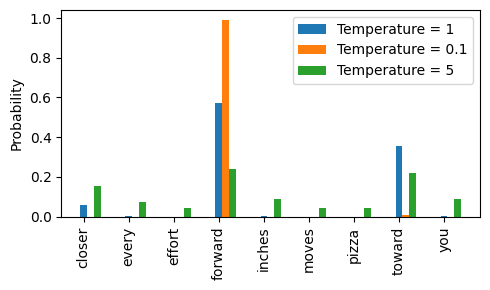

In [214]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
 rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### top k sampling

In [215]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [216]:
new_logits = torch.where(
 condition=next_token_logits < top_logits[-1],
 input=torch.tensor(float('-inf')),
 other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [217]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [218]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
 flat = token_ids.squeeze(0)
 return tokenizer.decode(flat.tolist())

In [219]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
    
        if top_k is not None:
             top_logits, _ = torch.topk(logits, top_k)
             min_val = top_logits[:, -1]
             logits = torch.where(
                 logits < min_val,
                 torch.tensor(float('-inf')).to(logits.device),
                 logits
             )
        if temperature > 0.0:
             logits = logits / temperature
             probs = torch.softmax(logits, dim=-1)
             idx_next = torch.multinomial(probs, num_samples=1)
        else:
             idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
                 break
        idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [220]:
torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT2_SMALL.context_length,
 top_k=40,
 temperature=4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you mafia


In [221]:
epoch = 1
model = GPT(GPT2_SMALL).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.1
)

In [245]:
class Trainer:
    def __init__(self,model,train_dataloader,val_dataloader,epoch,device,loss, accuracy, optimizer,scheduler,checkpointconfig):
        self.model = model
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.epoch = epoch
        self.device = device
        self.loss = loss
        self.accuracy = accuracy
        self.metrics = Metrics()
        self.global_step = 0
        self.epoch_step = 0
        self.best_val_loss = 99999
        self.checkpointconfig = checkpointconfig

    def _train_step(self,batch):
        x,y = batch
        x = x.to(self.device)
        y = y.to(self.device)
        self.optimizer.zero_grad()
        output = self.model(x)
        step_loss = self.loss(output, y)
        step_loss.backward()
        self.optimizer.step()
        self.scheduler.step()
        step_acc = self.accuracy(output, y)
        return step_loss.item(), step_acc.item()

    def _validate(self):
        val_loss , val_acc = calc_loss_accuracy_loader(self.model,self.device,self.val_dataloader)
        val_ppl = math.exp(val_loss)
        return val_loss, val_acc, val_ppl

    def _generate_sample_text(self):
        token_ids = generate(
                     model=self.model,
                     idx=text_to_token_ids("Every effort moves you", tokenizer),
                     max_new_tokens=15,
                     context_size=GPT2_SMALL.context_length,
                     temperature=1
                    )
        return token_ids_to_text(token_ids, tokenizer)
    
    def _save_checkpoint(self, BEST=False):
        if self.checkpointconfig.path is not None:
            path = Path(self.checkpointconfig.path)
            path.mkdir(parents=True, exist_ok=True)
            
            checkpoint = {
            "model": self.model.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "config": asdict(self.model.config),
            "scheduler":self.scheduler.state_dict(),
            "epoch_step": self.epoch_step,
            "global_step": self.global_step,
            "metrics": dict(self.metrics.metrics),
            "best_val_loss": self.best_val_loss
            }
            temp_file = path / "checkpoint.tmp"
            final_file = path / f"checkpoint_{self.global_step}.pt"
            
            ### save best file
            if BEST:
                final_file =path / f"best_checkpoint.pt"
                torch.save(checkpoint, temp_file)
                temp_file.replace(final_file) 
                print(f"Best checkpoint saved -> {final_file}")
                ### remove the previous best checkpoint
                for file in Path.joinpath(Path.cwd(),path).glob("best*"):
                    if final_file.name != file.name:
                        print(final_file,"removed")
                        file.unlink() 
            else:
                    
                torch.save(checkpoint, temp_file)
                temp_file.replace(final_file)   
                print(f"Checkpoint saved -> {final_file}")
                ### keeping only last n files
                file_list = []
                if self.checkpointconfig.keep_last_n:
                    for file in Path.joinpath(Path.cwd(),path).glob("checkpoint*"):
                        file_list.append(file)
                    if len(file_list) > self.checkpointconfig.keep_last_n:
                        files = sorted(file_list,key=lambda  p: int(p.stem.rsplit("_", 1)[1]))[:-1*self.checkpointconfig.keep_last_n]
                        [file.unlink() for file in files]
                

    def _resume_checkpoint(self, checkpoint_name):
        path = Path(self.checkpointconfig.path)
        checkpoint_path  = Path.joinpath(Path.cwd(),path , checkpoint_name)
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        self.model.config = ModelConfig(**checkpoint["config"])
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.scheduler.load_state_dict(checkpoint['scheduler'])
        self.epoch_step = checkpoint['epoch_step']
        self.global_step = checkpoint['global_step']
        self.metrics.metrics.update(checkpoint['metrics'])
        self.best_val_loss = checkpoint["best_val_loss"]
    
    def _train_epoch(self):
        epoch_loss,epoch_acc = 0,0
        for batch in tqdm(self.train_dataloader):
            step_loss, step_acc = self._train_step(batch)
            epoch_loss +=step_loss
            epoch_acc += step_acc
            self.global_step +=1
        epoch_ppl = math.exp(epoch_loss/len(self.train_dataloader))
        return epoch_loss/len(self.train_dataloader), epoch_acc/len(self.train_dataloader), epoch_ppl

    def fit(self, resume_latest=False, resume_best=False):
        if resume_latest:
            file_list=[]
            for file in Path.joinpath(Path.cwd(),self.checkpointconfig.path).glob("checkpoint*"):
                        file_list.append(file)
            latest_checkpoint_file = sorted(file_list,key=lambda  p: int(p.stem.rsplit("_", 1)[1]))[-1]
            self._resume_checkpoint(latest_checkpoint_file.name)
        if resume_best:
            self._resume_checkpoint('best_checkpoint.pt')
        for i in range(self.epoch_step,self.epoch):
            self.model.train()
            epoch_loss, epoch_acc, epoch_ppl = self._train_epoch()
            val_loss, val_acc, val_ppl = self._validate()
            self.metrics.update(
                                train_loss = epoch_loss,
                                train_acc = epoch_acc,
                                train_ppl = epoch_ppl,
                                val_loss = val_loss,
                                val_acc = val_acc,
                                val_ppl = val_ppl
                                )
            self.epoch_step +=1
            ### periodic saving
            if self.global_step % self.checkpointconfig.save_every_steps == 0:
                self._save_checkpoint()
            ### best saving
            if val_loss < self.best_val_loss :
                self.best_val_loss = val_loss
                self._save_checkpoint(BEST=self.checkpointconfig.save_best)
            print("Output text:\n", self._generate_sample_text())
            print(f"after {i+1} epoch global step {self.global_step} the train loss {epoch_loss} val loss {val_loss} and train acc| {epoch_acc} val acc| {val_acc} ")


In [242]:
trainer = Trainer(model,train_dataloader,val_dataloader, epoch, device, cross_entropy_loss, token_accuracy, optimizer, scheduler,CHECKPOINT_CONFIG)
trainer.fit()

  0%|          | 0/36 [00:00<?, ?it/s]

36 36
Checkpoint saved -> checkpoint_store/checkpoint_36.pt
Best checkpoint saved -> checkpoint_store/best_checkpoint.pt
checkpoint_store/best_checkpoint.pt removed
Output text:
 Every effort moves you livest
after 1 epoch global step 36 the train loss 11.022815942764282 val loss 11.079917907714844 and train acc| 0.0 val acc| 0.0 


  0%|          | 0/36 [00:00<?, ?it/s]

72 36
Checkpoint saved -> checkpoint_store/checkpoint_72.pt
Output text:
 Every effort moves you TJ
after 2 epoch global step 72 the train loss 11.020564715067545 val loss 11.079917907714844 and train acc| 0.0 val acc| 0.0 


  0%|          | 0/36 [00:00<?, ?it/s]

108 36
Checkpoint saved -> checkpoint_store/checkpoint_108.pt
Output text:
 Every effort moves you snatch
after 3 epoch global step 108 the train loss 11.022757954067654 val loss 11.079917907714844 and train acc| 0.0 val acc| 0.0 


  0%|          | 0/36 [00:00<?, ?it/s]

144 36
Checkpoint saved -> checkpoint_store/checkpoint_144.pt
Output text:
 Every effort moves you vers
after 4 epoch global step 144 the train loss 11.022005054685804 val loss 11.079917907714844 and train acc| 0.0 val acc| 0.0 


  0%|          | 0/36 [00:00<?, ?it/s]

180 36
Checkpoint saved -> checkpoint_store/checkpoint_180.pt
Output text:
 Every effort moves you">
after 5 epoch global step 180 the train loss 11.023861964543661 val loss 11.079917907714844 and train acc| 0.0 val acc| 0.0 


In [243]:
for pth in Path.joinpath(Path.cwd(),'checkpoint_store').iterdir():
    print(pth)

/kaggle/working/checkpoint_store/checkpoint_180.pt
/kaggle/working/checkpoint_store/checkpoint_108.pt
/kaggle/working/checkpoint_store/checkpoint_144.pt
/kaggle/working/checkpoint_store/best_checkpoint.pt


In [225]:
torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT2_SMALL.context_length,
 temperature=1
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youenegger


In [226]:
epoch = 5
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.1
)
model = GPT(GPT2_SMALL).to(device)

In [227]:
trainer.resume_checkpoint('checkpoint_108.pt')

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/checkpoint_store/checkpoint_108.pt'

In [ ]:
trainer.epoch 

In [ ]:
trainer.fit()

In [ ]:
for file in Path.joinpath(Path.cwd(),'checkpoints').glob("best*"):
                    if "best_checkpoint_180.pt" != file.name:
                        file.unlink()

In [ ]:
keep_last_n=3
file_list = []
for file in Path.joinpath(Path.cwd(),'checkpoints').glob("checkpoint*"):
    file_list.append(file)
if len(file_list) > keep_last_n:
    files = sorted(file_list,key=lambda  p: int(p.stem.rsplit("_", 1)[1]))[:-1*keep_last_n]
    [file.unlink() for file in files]

In [ ]:
import time
for i in tqdm(range(100)):
    time.sleep(0.1)